# Project Introduction: Multinomial Logistic Regression Analysis

### 1. Overview
This project focuses on the implementation and mathematical evaluation of **Multinomial Logistic Regression** (also known as **Softmax Regression**), a cornerstone algorithm in Supervised Machine Learning for multi-class classification tasks.

While Binary Logistic Regression handles exactly two categories using a single hyper-plane, Multinomial Logistic Regression scales this architecture to predict probabilities across three or more mutually exclusive target classes (e.g., Class 1, Class 2, or Class 3).

### 2. Why Binary Approaches Fail for Multi-Class Space
Attempting to use simple binary models to classify $K > 2$ unique classes creates two major structural issues:

1. **Uncalibrated Probabilities**: Running a "One-vs-Rest" (OvR) loop creates independent binary classifiers. Their output probabilities are not aware of each other, meaning they do not sum to $1.0$ and fail to create a true global probability distribution.

2. **Asymmetric Boundaries**: Independent binary models struggle with overlapping, complex multi-class data clusters, resulting in ambiguous regions where multiple classes claim dominance simultaneously.

### 3. Core Problem Statement
In this analysis, we address these multi-class processing limits. We aim to construct an integrated predictive engine that:
*   Maps multi-dimensional input features into a shared, bounded probability simplex where all class estimates sum exactly to $1.0$.
*   Derives an optimal set of **Linear Decision Boundaries** to cleanly separate multiple data clusters simultaneously.
*   Minimizes a multi-class cost function (**Multinomial Cross-Entropy Loss**) using an iterative **Gradient Descent** optimization strategy built entirely from scratch.

### 4. Technical Objectives
To achieve a deep, "from-scratch" understanding of the algorithm, this project is divided into the following modular phases:
*   **Mathematical Modeling**: Defining the **Softmax Activation Function** and the multidimensional parameter weight matrix $\Theta$ to compute class probabilities.
*   **Vectorized Implementation**: Leveraging **Linear Algebra (Matrix Notation)** to process datasets globally, replacing nested loops with fast matrix operations.
*   **Optimization**: Deriving and implementing the gradient calculus required to update model weights using the matrix error between predicted probabilities and one-hot encoded ground-truth targets.
*   **Performance Validation**: Generating continuous meshgrids across the input domain to visualize learned decision regions alongside real out-of-sample test points.

### 5. Key Terminology
*   **Hypothesis ($H$)**: The predicted probability matrix where each row is a valid probability distribution across $K$ classes.
*   **Logit ($Z$)**: The raw, unnormalized score matrix resulting from multiplying input features and parameters ($X\Theta$).
*   **One-Hot Encoding**: A binary bitmask mapping transformation that turns a scalar label into a vector filled with zeros except for a single $1$ at the correct class index.
*   **Cost Function ($J$)**: The multinomial cross-entropy error metric, derived via Maximum Likelihood Estimation and trace algebra.


## The Matrix Setup

Let $m$ be the total number of training sample rows, $n$ be the number of physical measured features, and $K$ be the total number of distinct target categories. We stack our features horizontally and prepend an artificial column of $1$s at index $0$ to handle the intercept bias vector. 

Unlike binary models which use a single weight vector, we expand our parameters into a full weight matrix $\Theta$ where each column manages the boundary slopes for a single target class. We arrange our ground-truth targets into a one-hot encoded matrix $Y$:

$$\underset{[m \times (n+1)]}{X} = \begin{bmatrix} 1 & x_1^{(1)} & x_2^{(1)} & \dots & x_n^{(1)} \\ 1 & x_1^{(2)} & x_2^{(2)} & \dots & x_n^{(2)} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_1^{(m)} & x_2^{(m)} & \dots & x_n^{(m)} \end{bmatrix}, \quad \underset{[m \times K]}{Y} = \begin{bmatrix} y_0^{(1)} & y_1^{(1)} & \dots & y_{K-1}^{(1)} \\ y_0^{(2)} & y_1^{(2)} & \dots & y_{K-1}^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ y_0^{(m)} & y_1^{(m)} & \dots & y_{K-1}^{(m)} \end{bmatrix}, \quad \underset{[(n+1) \times K]}{\Theta} = \begin{bmatrix} \theta_{00} & \theta_{01} & \dots & \theta_{0,K-1} \\ \theta_{10} & \theta_{11} & \dots & \theta_{1,K-1} \\ \vdots & \vdots & \ddots & \vdots \\ \theta_{n0} & \theta_{n1} & \dots & \theta_{n,K-1} \end{bmatrix}$$

### 3. The Vectorized Hypothesis Layer
To map unbounded linear combinations $Z = X\Theta$ into a valid probability distribution, we compute the row-wise **Softmax Activation Function**. For a specific data row vector $z^{(i)}$, the probability of belonging to class $c$ is:

$$P(y^{(i)} = c \mid x^{(i)}; \Theta) = \frac{\exp\left(z_c^{(i)}\right)}{\sum_{j=0}^{K-1} \exp\left(z_j^{(i)}\right)}$$

To prevent numerical overflow when computing large exponents, we subtract the maximum logit value of each row from its elements before exponentiation: $z_{\text{stable}}^{(i)} = z^{(i)} - \max(z^{(i)})$. This establishes our global **Hypothesis Matrix** ($H$):

$$\underset{[m \times K]}{H} = \text{softmax}(X\Theta) = \begin{bmatrix} h_{0}^{(1)} & h_{1}^{(1)} & \dots & h_{K-1}^{(1)} \\ h_{0}^{(2)} & h_{1}^{(2)} & \dots & h_{K-1}^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ h_{0}^{(m)} & h_{1}^{(m)} & \dots & h_{K-1}^{(m)} \end{bmatrix} = \begin{bmatrix} P(y^{(1)}=0 \mid x^{(1)}; \Theta) & \dots & P(y^{(1)}=K-1 \mid x^{(1)}; \Theta) \\ P(y^{(2)}=0 \mid x^{(2)}; \Theta) & \dots & P(y^{(2)}=K-1 \mid x^{(2)}; \Theta) \\ \vdots & \ddots & \vdots \\ P(y^{(m)}=0 \mid x^{(m)}; \Theta) & \dots & P(y^{(m)}=K-1 \mid x^{(m)}; \Theta) \end{bmatrix}$$

$$\text{Simplex Constraint Profile: } \sum_{c=0}^{K-1} h_{c}^{(i)} = 1 \quad \text{for all } i \in \{1, 2, \dots, m\}$$



In [3]:
import numpy as np
import matplotlib.pyplot as plt 

In [26]:
# ======================================
# MODULE 1: GENRATING SYNTHETIC DATA
# ======================================

def Multiclass_dataset(m_samples):
    
    """
    This module Genrates 3-classes (K=3) synthetic data sets 
    """
    #Number of classes
    global k 
    k=3
    
    #Activate Reproducibility
    np.random.seed(56)
    
    #data points per class 
    dpc = m_samples // k
    
    #Leftover data points 
    extra_data = m_samples % k
    
    data_size = [dpc]*k #extends the as [dpc, dpc, dpc] 
    
    #Adding extra data points into diffent classes one by one
    for i in range(extra_data):
        data_size[i] += 1
        
    # Genrating the classes 
    
    # Class 1: Center at [1.0,1.0] with standard deviation 0.4 
    X1 = np.random.normal(loc=[3.6,1.0], scale=0.4, size=(data_size[0],2)) 
    Y1 = np.zeros((data_size[0],1),dtype=int) # Ground truth values for X1
    
    # Class 2: Center at [3.0,4.5] with standard deviation 0.6
    X2 = np.random.normal(loc=[3.0,4.5], scale=0.6, size=(data_size[1],2))
    Y2 = np.ones((data_size[1],1), dtype=int)
    
    #  Class 3: Center at [5.0,2.5] with standard deviation 0.6
    X3 = np.random.normal(loc=[5.0,2.5], scale=0.6, size=(data_size[2],2))
    Y3 = np.ones((data_size[2],1), dtype=int)*2
    
    #Combining into global matrix 
    
    X = np.concatenate([X1, X2, X3], axis=0)
    y = np.concatenate([Y1, Y2, Y3],axis=0)
    
    # Shuffling the feature matrix and target vector
    indices = np.random.permutation(m_samples)
    X = X[indices]
    y = y[indices]
    
    return X, y

print("--- Data Genrated succssfully --- ") 
X_raw, y_raw = Multiclass_dataset(1000)

print(f"Dimension of X : {X_raw.shape}")
print(f"Dimension of y : {y_raw.shape}")    
      
        
    
    

--- Data Genrated succssfully --- 
Dimension of X : (1000, 2)
Dimension of y : (1000, 1)


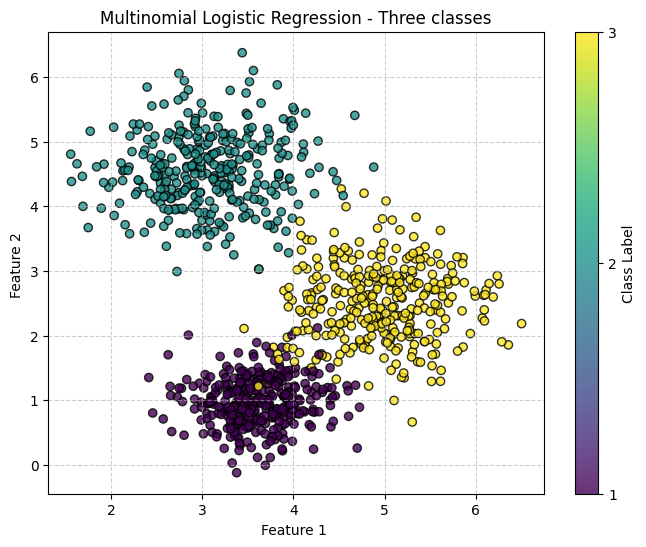

In [27]:
# ============================================
# MODULE 2: VISULISATION OF FEATURE MATRIX X
# ============================================

# --- Visualization ---
plt.figure(figsize=(8, 6))

# Scatter plot: Feature 1 on X-axis, Feature 2 on Y-axis
# 'c=y_raw.ravel()' to color points by their class (1, 2, or 3)
scatter = plt.scatter(X_raw[:, 0], X_raw[:, 1], 
                      c=y_raw.ravel(), cmap='viridis', edgecolor='k', alpha=0.8)

# Add labels and title
plt.xlabel('Feature 1 ')
plt.ylabel('Feature 2 ')
plt.title('Multinomial Logistic Regression - Three classes')

# Add a colorbar to show which color maps to which class
cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.set_ticklabels(['1', '2', '3'])
cbar.set_label('Class Label')


plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Matrix Calculus Derivation of the Gradient

Because our non-linear Softmax maps variables across interdependent columns that must sum to $1$, we cannot calculate a simple closed-form algebraic solution. We must derive the gradient matrix $\nabla_\Theta J(\Theta)$ to find our updates. We apply the **Multivariate Vector Chain Rule**:

$$\frac{\partial J(\Theta)}{\partial \Theta} = \left( \frac{\partial H}{\partial \Theta} \right)^T \frac{\partial J(\Theta)}{\partial H}$$

### Step A: Differentiate Cost with respect to Hypothesis Matrix $\left(\frac{\partial J(\Theta)}{\partial H}\right)$
We differentiate our scalar cross-entropy loss $J(\Theta)$ with respect to our full estimated probability matrix $H$:

$$\frac{\partial J(\Theta)}{\partial H} = -\frac{1}{m} \left( \frac{Y}{H} \right)$$

*(Note: The fraction line here denotes element-wise division between matrices).*

### Step B: Differentiate Softmax Layer with respect to Raw Parameters $\left(\frac{\partial H}{\partial \Theta}\right)$
The derivative of the Softmax function outputs two different forms depending on whether the indices match. Evaluating the quotient rule shows that $\frac{\partial h_i}{\partial z_j} = h_i(1 - h_i)$ when $i=j$, and $-h_i h_j$ when $i \neq j$. 

When written in matrix form, this expands into a block diagonal structure. Using the linear matrix derivative rule $\frac{\partial(X\Theta)}{\partial \Theta} = X$, we complete this leg of the chain rule:

$$\frac{\partial H}{\partial \Theta} = \frac{\partial H}{\partial Z} \cdot \frac{\partial Z}{\partial \Theta} = \frac{\partial H}{\partial Z} \cdot X$$

### Step C: Collapse the Matrix Chain Rule Elements
We substitute Step A and Step B back into our master chain rule equation. The block matrices simplify cleanly. The matching and non-matching components combine to cancel out the denominator terms from the loss function:

$$\frac{\partial J(\Theta)}{\partial \Theta} = \frac{1}{m} X^T (H - Y)$$

Expanding this matrix product confirms that our dimensions remain perfectly aligned throughout the update process:

$$\underset{[(n+1) \times K]}{\nabla_\Theta J(\Theta)} = \frac{1}{m} \cdot \underset{[(n+1) \times m]}{X^T} \cdot \underset{[m \times K]}{(H - Y)}$$

### Step D: Vectorized Gradient Descent Update Rule
We subtract the scaled gradient matrix from our parameter matrix to iteratively shift our decision boundaries and minimize the global cross-entropy loss:

$$\Theta := \Theta - \alpha \cdot \left[ \frac{1}{m} X^T (H - Y) \right]$$


#  The Softmax Activation Function

To handle $K$ target classes, our model outputs a raw vector of real numbers called **logits** ($\mathbf{z}$). Logits can be negative, positive, or zero, and they do not sum to $1.0$. We cannot use these raw values directly as class probabilities. 

The **Softmax function** bridges this gap. It acts as an activation layer that transforms these raw logit scores into an ordered probability distribution by performing two operations:
1. **Exponentiation ($e^{z_i}$)**: Converts all negative scores into positive values and accentuates larger differences between scores.
2. **Normalization ($\sum e^{z_j}$)**: Divides each exponentiated score by the sum of all exponentiated scores, forcing the final outputs to fall strictly between $0$ and $1$ and sum exactly to $1.0$.

### Mathematical Formulation
For a single data point yielding a logit vector $\mathbf{z} = [z_1, z_2, \dots, z_K]^T$, the Softmax activation for a specific class $i$ is defined as:

$$P(y = i \mid \mathbf{z}) = \sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Where:
* $K$ is the total number of classes.
* $z_i$ is the raw logit score assigned to class $i$.


# Target Representation & Probability Mapping Space

### 1. Overview
To systematically compute our model's classification errors across a multi-class configuration, we must map continuous predictions directly against discrete truth profiles. 

This requires transforming our raw unnormalized boundaries ($Z$) through a row-wise Softmax operator to construct a continuous **Hypothesis Probability Matrix** ($H$). Simultaneously, we project scalar true class integers into an identical structural dimension by encoding labels into a binary bitmask **Target Matrix** ($Y$).

### 2. The Vectorized Probability Mapping Layer
To convert raw logits into valid probability profiles, we apply the Softmax activation layer across each index row. This maps coordinates onto a bounded categorical spectrum, constructing our **Hypothesis Matrix** ($H$):

$$\underset{[m \times K]}{H} = \text{softmax}(X\Theta) = \begin{bmatrix} h_{0}^{(1)} & h_{1}^{(1)} & \dots & h_{K-1}^{(1)} \\ h_{0}^{(2)} & h_{1}^{(2)} & \dots & h_{K-1}^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ h_{0}^{(m)} & h_{1}^{(m)} & \dots & h_{K-1}^{(m)} \end{bmatrix}$$

$$\text{Where row distributions are constrained by: } h_{c}^{(i)} = \frac{\exp\left(z_c^{(i)}\right)}{\sum_{j=0}^{K-1} \exp\left(z_j^{(i)}\right)} \quad \text{such that} \quad \sum_{c=0}^{K-1} h_{c}^{(i)} = 1$$

### 3. The One-Hot Encoded Ground-Truth Target Space
We expand discrete categorical labels ($y^{(i)} \in \{0, 1, \dots, K-1\}$) into a multi-column array matching our prediction layout. Only the column index corresponding to the true target class is flagged active ($1$), leaving alternative class channels disabled ($0$):

$$\underset{[m \times K]}{Y} = \begin{bmatrix} y_0^{(1)} & y_1^{(1)} & \dots & y_{K-1}^{(1)} \\ y_0^{(2)} & y_1^{(2)} & \dots & y_{K-1}^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ y_0^{(m)} & y_1^{(m)} & \dots & y_{K-1}^{(m)} \end{bmatrix}$$

$$\text{Where individual cell values are determined by: } y_{c}^{(i)} = \begin{cases} 1 & \text{if the true ground label of sample } i \text{ is } c \\ 0 & \text{otherwise} \end{cases}$$



In [6]:
# =====================================================
# MODULE 3: MATRIX PIPELINE STRUCTURAL TRANSFORMATIONS 
# =====================================================

def one_hot_encoding_targrt(y_intergers):
    
    """ Transforming [mx1] integer array into an [m x k] binary matrix"""
    
    y_flat = y_intergers.ravel()
    
    #Number of samples 
    m = len(y_flat)
    
    y_encoded = np.zeros((m,k))
    y_encoded[np.arange(m), y_flat] = 1.0
    
    return y_encoded




def softmax_activation(Z_scores):
    
    """
    Applying the stable normalization row-by-row across matrix z
    Subtracting the row maximums for numerical stability
    """
    
    # Maximum value in each row
    row_max = np.max(Z_scores, axis=1, keepdims=True)
    
    #Subtracting row_max from each row to prevent exponential overflow 
    exp_shifted = np.exp(Z_scores - row_max)
    
    # Sum of all exponent values 
    row_sums = np.sum(exp_shifted, axis=1, keepdims=True)
    
    #Probability matrix H
    H = exp_shifted / row_sums
    
    return H 


 



# Matrix Calculus Derivation of the Gradient

Because our non-linear Softmax maps variables across interdependent columns that must sum to $1$, we cannot calculate a simple closed-form algebraic solution. We must derive the gradient matrix $\nabla_\Theta J(\Theta)$ to find our updates. We apply the **Multivariate Vector Chain Rule**:

$$\frac{\partial J(\Theta)}{\partial \Theta} = \left( \frac{\partial H}{\partial \Theta} \right)^T \frac{\partial J(\Theta)}{\partial H}$$

### Step A: Differentiate Cost with respect to Hypothesis Matrix $\left(\frac{\partial J(\Theta)}{\partial H}\right)$
We differentiate our scalar cross-entropy loss $J(\Theta)$ with respect to our full estimated probability matrix $H$:

$$\frac{\partial J(\Theta)}{\partial H} = -\frac{1}{m} \left( \frac{Y}{H} \right)$$

*(Note: The fraction line here denotes element-wise division between matrices).*

### Step B: Differentiate Softmax Layer with respect to Raw Parameters $\left(\frac{\partial H}{\partial \Theta}\right)$
The derivative of the Softmax function outputs two different forms depending on whether the indices match. Evaluating the quotient rule shows that $\frac{\partial h_i}{\partial z_j} = h_i(1 - h_i)$ when $i=j$, and $-h_i h_j$ when $i \neq j$. 

When written in matrix form, this expands into a block diagonal structure. Using the linear matrix derivative rule $\frac{\partial(X\Theta)}{\partial \Theta} = X$, we complete this leg of the chain rule:

$$\frac{\partial H}{\partial \Theta} = \frac{\partial H}{\partial Z} \cdot \frac{\partial Z}{\partial \Theta} = \frac{\partial H}{\partial Z} \cdot X$$

### Step C: Collapse the Matrix Chain Rule Elements
We substitute Step A and Step B back into our master chain rule equation. The block matrices simplify cleanly. The matching and non-matching components combine to cancel out the denominator terms from the loss function:

$$\frac{\partial J(\Theta)}{\partial \Theta} = \frac{1}{m} X^T (H - Y)$$

Expanding this matrix product confirms that our dimensions remain perfectly aligned throughout the update process:

$$\underset{[(n+1) \times K]}{\nabla_\Theta J(\Theta)} = \frac{1}{m} \cdot \underset{[(n+1) \times m]}{X^T} \cdot \underset{[m \times K]}{(H - Y)}$$

### Step D: Vectorized Gradient Descent Update Rule
We subtract the scaled gradient matrix from our parameter matrix to iteratively shift our decision boundaries and minimize the global cross-entropy loss:

$$\Theta := \Theta - \alpha \cdot \left[ \frac{1}{m} X^T (H - Y) \right]$$



In [ ]:
# =========================================
# MODULE 4: MODEL TRAINING & OPTIMIZATION
# =========================================


def train_softmax_regression(X_train, y_train, lr, epochs):
    
    # Training the parmeter matrix theta
    m, n = X_train.shape
    
    # 1. Formating the design Matrix by prepending the bias column of 1s
    X_desgin = np.hstack([np.ones((m,1)), X_train])
    
    
    # 2. Transforming the target label into an [m x k] matrix
    Y_encoded = one_hot_encoding_targrt(y_train)
    
    # 3. Initilizing the global parameter Matrix theta . shape :[(n+1), K]
    theta = np.zeros((n+1, k))
     
    # Accumulating the loss history 
    loss_hist = []
    
    # Thata optimization loop
    for epoch in range(epochs):
        
        # Calculating raw Matrix logits : Z = X_design @ theta
        Z = X_desgin @ theta
        
        # Computing row-by-row softmax probabilities : H
        H = softmax_activation(Z)
        
        # Categorical cross entropy loss scalar
        cross_entropy_loss = -(1/m) * np.sum(Y_encoded * np.log(H + 1e-15)) # To avoid log(1) and log(0)
        loss_hist.append(cross_entropy_loss)
        
        # Computing dradient descent 
        gradient = (1/m) * X_desgin.T @ (H - Y_encoded)
        
        # Updating the theta value over every epoch
        theta -= lr * gradient
        
    return theta, loss_hist    
        

        

# Model Training Phase & Empirical Optimization Dynamics

### 1. Theoretical Grounding of Data Partitioning
In machine learning, fitting parameters to an entire dataset introduces a severe risk of **Overfitting**—where the model memorizes noise and specific variances of the training data rather than learning the underlying distribution. 

To evaluate a model's true generalization capacity, we apply a cross-validation strategy via `train_test_split`. This partitions our raw matrices ($X_{\text{raw}}, Y_{\text{raw}}$) into two distinct, statistically independent subsets based on a defined ratio ($\alpha_{\text{test}} = 0.2$):
*   **Training Set ($X_{\text{train}}, Y_{\text{train}}$)**: The *Optimization Space* ($80\%$ of the data), used by the Gradient Descent loop to compute empirical loss gradients and update the parameters $\Theta$.
*   **Testing Set ($X_{\text{test}}, y_{\text{test}}$)**: The *Inference Validation Space* ($20\%$ of the data), completely hidden from the optimization phase, used exclusively to score the model's true predictive power on unseen data.

The parameter `random_state=56` locks the pseudorandom number generator's seed. This ensures that the rows are shuffled identically across executions, ensuring **Reproducibility** of data splits and optimization curves.

### 2. Hyperparameter Configuration
Unlike model parameters ($\Theta$) which are calculated mathematically during training, **Hyperparameters** are external operational structures that must be predefined before the optimization loop starts:
*   **Learning Rate ($\eta = 0.1$)**: The step-size multiplier. It scales the magnitude of parameter updates at each iteration. If set too high, optimization will overshoot the global minimum and diverge; if set too low, training will stall and require excessive computational time.
*   **Epochs ($700$)**: The complete training duration. One epoch represents one full forward and backward pass of the entire training matrix $X_{\text{train}}$ through the optimization engine.

### 3. Empirical Interpretation of the Optimization Curve
The plotted red curve represents the **Loss History Vector**, visualizing the value of our Multinomial Cross-Entropy Cost Function $J(\Theta)$ across successive gradient iterations:

*   **Asymptotic Decay Dynamics**: The steep initial drop indicates that the randomly initialized weights are rapidly adjusting to align with the primary linear boundaries of the data classes. 
*   **Convergence Verification**: As the number of epochs approaches $700$, the curve flattens out, and the gradient of the loss vector ($\nabla_\Theta J(\Theta)$) approaches zero. This asymptotic stabilization mathematically confirms that the parameters have converged inside a stable **Global Minimum** of our convex cross-entropy loss landscape.

### 4. Minimum Loss Metric
The value `np.min(loss)` extracts the lowest cost score achieved across the entire training history. In an ideal optimization run, this minimum is reached on the very last epoch ($700$). This scalar serves as our empirical baseline, indicating how tightly the learned soft classification boundaries match the training labels.


Minimum loss :0.1756


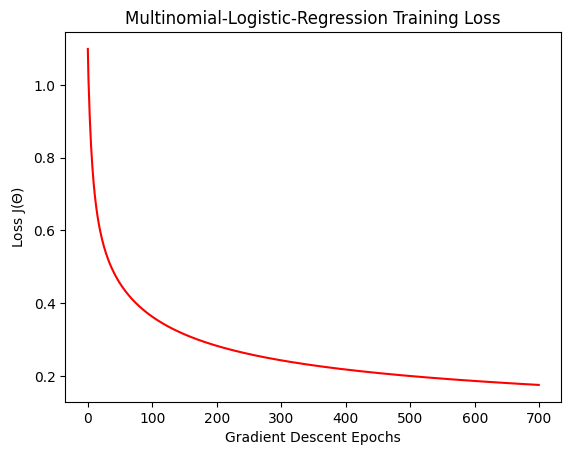

In [ ]:
# ========================================
# MODULE 5: CROSS-ENTROPY LOSS EVALUATION 
# ========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=56)

#Intitial parameters 
learning_rate= 0.1
epochs = 700 
theta_trained, loss = train_softmax_regression(X_train, y_train, learning_rate, epochs)

print(f"Minimum loss :{np.min(loss):.4f}")

plt.plot(loss, color='red')
plt.xlabel('Gradient Descent Epochs')
plt.ylabel(r'Loss J($\Theta$)')
plt.title('Multinomial-Logistic-Regression Training Loss')
plt.show()


# Vectorized Inference Mechanics & Adaptive Input Processing

### 1. Theoretical Grounding of the Inference Pipeline
Once our parameter weight matrix ($\Theta$) is optimized, the model enters the **Inference Phase**, where its purpose shifts from learning boundaries to deploying them. 

The inference pipeline completely bypasses the true target matrix ($Y$) and executes a forward pass on new, unclassified observations. This function performs two consecutive mathematical steps:
1.  **Continuous Probability Density Mapping**: Translating raw boundary positions into valid conditional probabilities.
2.  **Discrete Hard Class Selection**: Converting continuous probability profiles into a final, definitive classification label.

### 2. Algorithmic Dimension Protection & Intercept Injection
To ensure high utility and robustness in real-world deployment, our inference function is engineered with adaptive input checking. This guarantees structural alignment with our learned parameters before performing matrix operations:

*   **1D Scalar Flattening to 2D Array**: If a single sample is fed into the system as a 1D vector (`x_query.ndim == 1`), the system reshapes it into a 2D row matrix (`1, -1`). This allows the exact same linear algebra code to handle both a single out-of-sample data point and a massive parallelized batch of data points simultaneously.
*   **Dynamic Bias Vector Injection**: If incoming data features do not contain the leading baseline intercept column, the system catches the mismatch (`x_query.shape[1] == theta_train.shape[0] - 1`) and prepends a column of solid $1.0$ constants along `axis=1`. This aligns the dimensions so that the input matrix can be multiplied directly with our learned weights.

### 3. The Linear Projection & Decision Calculus
With structural dimensions protected, the input array undergoes a raw matrix multiplication with our parameter weights, producing our **Logit Score Matrix** ($Z$):

$$\underset{[m_{\text{query}} \times K]}{Z} = \underset{[m_{\text{query}} \times (n+1)]}{X_{\text{query}}} \cdot \underset{[(n+1) \times K]}{\Theta_{\text{trained}}}$$

These raw, unconstrained scores are fed directly into the row-wise `softmax_activation` to output valid, calibrated multi-class fractional probabilities ($H$).

To make a final categorical assignment, the engine evaluates the row space using an index maximization operator (`np.argmax`). This extracts the column coordinate containing the absolute highest probability:

$$\hat{y}^{(i)} = \arg\max_{c \in \{0, 1, \dots, K-1\}} \left( h_{c}^{(i)} \right)$$

### 4. Mathematical Optimization for Inference Speed
Because the denominator of the Softmax activation function acts as a uniform positive scaling factor across all classes for any single row, and because exponentiating a number preserves its relative order (monotonically increasing profile), we can bypass the Softmax step entirely if our only goal is to find the hard class prediction:

$$\hat{y}^{(i)} = \arg\max_{c} \left( \frac{\exp\left(z_c^{(i)}\right)}{\sum_j \exp\left(z_j^{(i)}\right)} \right) \equiv \arg\max_{c} \left( z_c^{(i)} \right)$$

However, our code deliberately retains the full pipeline because displaying the exact confidence profile across all categories is critical for verifying how certain the model is when making predictions on edge cases.


In [ ]:
# ===============================================
# MODULE 6: MODEL PREDICTION & CLASS ALLOTMENT 
# ===============================================

def predict_multiclass(x_query, theta_train):
    """
    Processes incoming feature vector(s) and outputs soft probabilities
    and hard class assignments.
    - x_query: 1D array (single sample) or 2D array (batch).
    - theta_train: trained parameter matrix.
    Returns:
      - probabilities: shape (n_samples, K) or (K,) for single
      - class_assignments: array of predicted class indices
    """
    # If a single sample (1D), convert to 2D row vector
    if x_query.ndim == 1:
        x_query = x_query.reshape(1, -1)
    
    # If bias column is missing (shape[1] == theta_train.shape[0] - 1), add it
    if x_query.shape[1] == theta_train.shape[0] - 1:
        x_query = np.insert(x_query, 0, 1.0, axis=1)
    
    # Now x_query is (n_samples, n+1) and matches theta_train's rows
    z_scores = x_query @ theta_train          # (n_samples, K)
    probabilities = softmax_activation(z_scores)  # same shape
    class_assignments = np.argmax(probabilities, axis=1)  # (n_samples,)
    
    # For single sample, return 1D arrays for convenience
    if probabilities.shape[0] == 1:
        return probabilities.ravel(), int(class_assignments[0])
    else:
        return probabilities, class_assignments

# Comprehensive Diagnostic Validation & Multi-Class Performance Metrics

### 1. Theoretical Grounding of Multi-Class Evaluation
Evaluating a multi-class system requires metrics that look beyond simple accuracy scores. When datasets have class imbalances, high overall accuracy can mask a model's complete inability to correctly predict a rare but critical target category. 

To prevent this blind spot, our verification suite runs our validation data matrix ($X_{\text{test}}$) through our prediction engine. We then compare the predicted labels against our hidden true labels ($y_{\text{true}}$) across four fundamental classification metrics: **Accuracy**, **Precision**, **Recall**, and the **F1-Score**.

### 2. Multi-Class Averaging Heuristics
In binary setups, precision and recall target a single positive class. In a multi-class configuration ($K \ge 3$), we evaluate these metrics using a **Macro-Averaging Approach** (`average='macro'`). 

Macro-averaging calculates the metric independently for each individual category, treating it as a binary classification problem, and then computes the unweighted arithmetic mean across all classes:

$$\text{Metric}_{\text{macro}} = \frac{1}{K} \sum_{c=0}^{K-1} \text{Metric}_c$$

This approach treats all classes equally, regardless of how many samples they contain. As a result, any performance drops in minor categories are highlighted immediately, making it a robust way to evaluate true model generalization.

### 3. Deconstructing the Diagnostic Metric Suite
*   **Accuracy Score**: The overall fraction of correct predictions across the entire test matrix. While intuitive, it does not reveal where classification errors are happening.
    $$\text{Accuracy} = \frac{\sum_{i=1}^{m_{\text{test}}} \mathbb{I}(\hat{y}^{(i)} = y_{\text{true}}^{(i)})}{m_{\text{test}}}$$
*   **Precision (Macro)**: Measures our model's specificity. It answers: *Of all items the model flagged as belonging to Class $c$, what percentage actually belonged to that class?* High precision means a low false-positive rate.
    $$\text{Precision}_c = \frac{\text{True Positives}_c}{\text{True Positives}_c + \text{False Positives}_c}$$
*   **Recall (Macro)**: Measures our model's sensitivity. It answers: *Of all true samples that actually belonged to Class $c$, what percentage did our model successfully find?* High recall means a low false-negative rate.
    $$\text{Recall}_c = \frac{\text{True Positives}_c}{\text{True Positives}_c + \text{False Negatives}_c}$$
*   **F1-Score (Macro)**: The harmonic mean of precision and recall. Unlike a simple average, the harmonic mean drops sharply if either precision or recall is weak, making it a reliable single metric for tracking model balance.
    $$\text{F1-Score}_c = 2 \cdot \frac{\text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

### 4. Decoding the Structural Geometry of the Confusion Matrix
The **Confusion Matrix** provides a detailed look at classification performance. It maps true categories to row indexes and predicted categories to column indexes, creating a clear matrix structure:

$$\mathbf{C} = \begin{bmatrix} 
C_{00} & C_{01} & C_{02} \\ 
C_{10} & C_{11} & C_{12} \\ 
C_{20} & C_{21} & C_{22} 
\end{bmatrix}$$

*   **The Main Diagonal ($C_{ii}$)**: Represents correct predictions where the true label matches the predicted label. An ideal model concentrates all values here, leaving the rest of the matrix at zero.
*   **Off-Diagonal Elements ($C_{ij}, i \neq j$)**: Represents classification errors. For example, entry $C_{12}$ counts how many times a sample that actually belonged to Class 1 was incorrectly classified as Class 2. This mapping pinpoints exactly which categories the model is confusing.


In [ ]:
# ==========================================
# MODULE 7: MODLE EVALUATION (Custom Model) 
# ==========================================


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred, class_assign = predict_multiclass(X_test, theta_trained)
y_true = y_test.ravel()

print("--- Model Score Board ---")
print(f"Accuracy of the Model : {100 * accuracy_score(y_true, class_assign):.2f}%")
print(f"Precision (macro): {precision_score(y_true, class_assign, average='macro'):.4f}")
print(f"Recall    (macro): {recall_score(y_true, class_assign, average='macro'):.4f}")
print(f"F1 Score  (macro): {f1_score(y_true, class_assign, average='macro'):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, class_assign))

--- Model Score Board ---
Accuracy of the Model : 95.00%
Precision (macro): 0.9511
Recall    (macro): 0.9502
F1 Score  (macro): 0.9505

Confusion Matrix:
[[66  0  4]
 [ 0 65  0]
 [ 6  0 59]]


In [ ]:
# ============================================
# MODULE 8: MODLE EVALUATION (Sci-kit Learn ) 
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score

clf = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=1000))
scores = cross_val_score(clf, X_raw, y_raw.ravel(), cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

CV Accuracy: 0.9750 ± 0.0055


# Out-of-Sample Inference Geometry & Continuous Decision Space Mapping

### 1. Theoretical Grounding of Spatial Decision Topology
Once a multi-class predictive engine finishes its training optimization, its learned linear boundaries split the continuous feature space into distinct, non-overlapping sectors called **Decision Regions**. Every coordinate inside a given region maps to the same primary class assignment. 

To visualize this hidden geometric structure, we construct an evaluation script that maps out-of-sample test coordinates (`new_points`) and samples a dense coordinate grid across the entire domain. This process maps out our boundaries and visually reveals how certain our model is when making predictions near the edges of different regions.

### 2. Deconstructing the Coordinate Grid Architecture
The algorithm uses a continuous sampling method to find and highlight the exact lines where our classification boundaries shift:
*   **Coordinate Domain Expansion**: The script collects the minimum and maximum coordinates from both the training observations and our new test points. It expands these boundaries by a small safety margin ($\pm 0.5$) to ensure no data points are cut off at the edges of the plot.
*   **Meshgrid Generation (`np.meshgrid`)**: The space is divided into a high-resolution $300 \times 300$ grid. This creates $90,000$ unique intersection coordinates (`grid_points`) that completely fill the two-dimensional feature space.
*   **Parallel Spatial Inference**: The entire batch of grid coordinates is passed through `predict_multiclass`. The system calculates the highest logit score for each point and reshapes the outputs back into a structured matrix (`grid_pred`). This creates a complete map of predictions across the entire feature space.

### 3. Visual Representation of Class Domains
The mapping script uses two separate colormaps to clearly show the difference between continuous decision regions and individual data points:
*   **Continuous Decision Regions (`ax.contourf`)**: Uses a soft, low-opacity colormap (`cmap_light`) to fill the background. These shaded areas mark the continuous domains where Class 1, Class 2, or Class 3 hold the highest probability. The borders where these colors change mark the exact paths of our linear decision boundaries.
*   **Empirical Reference Data (`ax.scatter`)**: The original training data points are plotted on top using a vivid, high-contrast colormap (`cmap_bold`). This lets us instantly check the quality of our boundaries by seeing how cleanly the background color matches the actual data clusters.

### 4. Analysis of Out-of-Sample Test Points
To test how well the model handles completely new data, six custom test points are dropped into the space. Their behavior across the boundaries reveals several key insights:



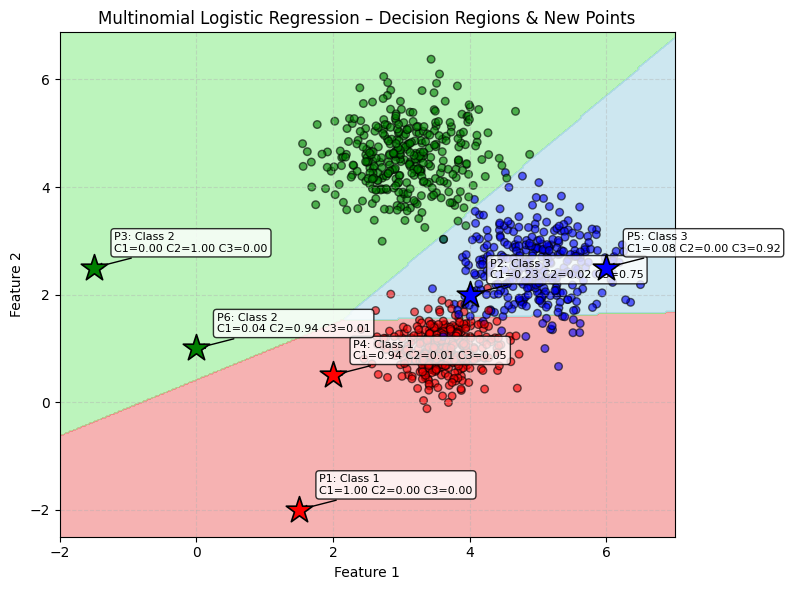

Point     Feat1    Feat2      C1       C2        C3    Predicted
---------------------------------------------------------------------------
P1         1.50    -2.00   0.9999   0.0000   0.0001      Class 1
P2         4.00     2.00   0.2307   0.0180   0.7513      Class 3
P3        -1.50     2.50   0.0000   1.0000   0.0000      Class 2
P4         2.00     0.50   0.9388   0.0065   0.0546      Class 1
P5         6.00     2.50   0.0830   0.0004   0.9167      Class 3
P6         0.00     1.00   0.0431   0.9446   0.0122      Class 2


In [39]:
# =============================================================
# MODULE 9: MODEL PREDICTION VISUALISATION  & CLASS ALLOTMENT  
# ============================================================


# Defining new points 
new_points = np.array([
    [ 1.5, -2.0],
    [ 4.0,  2.0],
    [-1.5,  2.5],
    [ 2.0,  0.5],
    [ 6.0,  2.5],
    [ 0.0,  1.0],

])

# Predict for new points (returns probabilities and class indices 0,1,2)
new_probs, new_preds = predict_multiclass(new_points, theta_trained)

#  Compute combined min/max 
all_x = np.concatenate([X_raw[:, 0], new_points[:, 0]])
all_y = np.concatenate([X_raw[:, 1], new_points[:, 1]])

x_min, x_max = all_x.min() - 0.5, all_x.max() + 0.5
y_min, y_max = all_y.min() - 0.5, all_y.max() + 0.5

# Create mesh grid 
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid_points = np.c_[xx.ravel(), yy.ravel()]

_, grid_pred = predict_multiclass(grid_points, theta_trained)
grid_pred = grid_pred.reshape(xx.shape)   # still 0,1,2

# Plotting  
fig, ax = plt.subplots(figsize=(8, 6))

# Colormaps: order is class 0 -> color1, class 1 -> color2, class 2 -> color3
cmap_light = ListedColormap(['lightcoral', 'lightgreen', 'lightblue'])
cmap_bold  = ListedColormap(['red', 'green', 'blue'])

# Decision regions
ax.contourf(xx, yy, grid_pred, cmap=cmap_light, alpha=0.6)

# Training data (y_raw has 0,1,2; we can use same colormap)
sc = ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y_raw.ravel(), cmap=cmap_bold,
                edgecolor='k', s=30, alpha=0.6, label='Training data')

# Plot new points as stars with annotations 
for i, (pt, pred_idx, probs) in enumerate(zip(new_points, new_preds, new_probs)):
    
    # pred_idx is 0,1,2 -> map to class number 1,2,3
    class_label = pred_idx + 1
    color = cmap_bold.colors[pred_idx]
    ax.scatter(pt[0], pt[1], c=[color], marker='*', s=400,
               edgecolors='black', linewidths=1.2, zorder=5)
    
    # Show probabilities for each class (1,2,3)
    label = (f"P{i+1}: Class {class_label}\n"
             f"C1={probs[0]:.2f} C2={probs[1]:.2f} C3={probs[2]:.2f}")
    ax.annotate(label, xy=(pt[0], pt[1]),
                xytext=(pt[0] + 0.3, pt[1] + 0.3),
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Multinomial Logistic Regression – Decision Regions & New Points')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Summary table with classes 1,2,3 ---
print(f"{'Point':<6} {'Feat1':>8} {'Feat2':>8} " +
      f"{'C1 ':>8} {'C2 ':>8} {'C3':>8} {'Predicted':>12}")
print("-" * 75)
for i, (pt, probs, pred_idx) in enumerate(zip(new_points, new_probs, new_preds)):
    class_label = pred_idx + 1
    print(f"P{i+1:<5} {pt[0]:>8.2f} {pt[1]:>8.2f} " +
          f"{probs[0]:>8.4f} {probs[1]:>8.4f} {probs[2]:>8.4f} " +
          f"{'Class ' + str(class_label):>12}")